# 01 · Data validation and exploration

A reproducible look at the dataset contract that starts the MLOps pipeline. This notebook uses the same loader and validator as the training service—there is no notebook-only copy of the data logic.

## Objectives

- Load the versioned Iris dataset through the project package.
- Inspect schema, ranges, missingness, and target balance.
- Visualize whether the features contain useful class separation.
- Demonstrate that invalid data fails before training.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from mlops_demo.data import Dataset, load_dataset, validate_dataset

plt.style.use("dark_background")
ACCENT = "#76B900"
CLASS_COLORS = {"setosa": "#76B900", "versicolor": "#00BFA5", "virginica": "#F59E0B"}

## Load the validated dataset

`load_dataset()` normalizes the feature names and calls `validate_dataset()` before returning any data. A contract violation therefore stops the pipeline at its boundary.

In [2]:
dataset = load_dataset()
frame = dataset.features.copy()
frame["species"] = dataset.target.map(dict(enumerate(dataset.target_names)))

print(
    f"{len(frame)} samples · {len(dataset.features.columns)} features · "
    f"{len(dataset.target_names)} classes"
)
frame.head()

150 samples · 4 features · 3 classes


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Inspect the contract

Every model input must be numeric, complete, and non-negative. The summary below makes those assumptions visible before any estimator is fitted.

In [3]:
contract = pd.DataFrame(
    {
        "dtype": dataset.features.dtypes.astype(str),
        "missing": dataset.features.isna().sum(),
        "minimum": dataset.features.min(),
        "mean": dataset.features.mean(),
        "maximum": dataset.features.max(),
    }
).rename_axis("feature")
contract.round(3)

,dtype,missing,minimum,mean,maximum
feature,,,,,
sepal_length_cm,float64,0,4.3,5.843,7.9
sepal_width_cm,float64,0,2.0,3.057,4.4
petal_length_cm,float64,0,1.0,3.758,6.9
petal_width_cm,float64,0,0.1,1.199,2.5


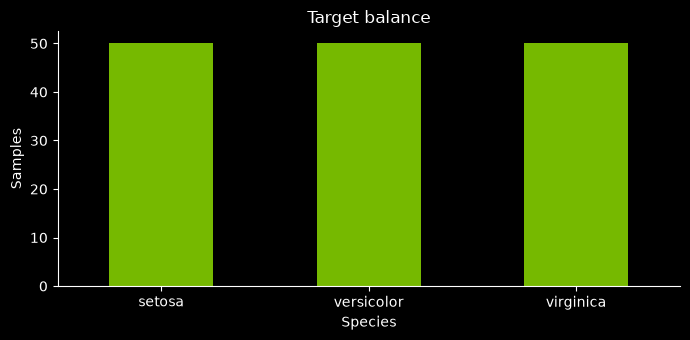

In [4]:
class_counts = frame["species"].value_counts().reindex(dataset.target_names)
ax = class_counts.plot.bar(color=ACCENT, figsize=(7, 3.5), rot=0)
ax.set(title="Target balance", xlabel="Species", ylabel="Samples")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Check feature separation

Petal length and sepal length already reveal meaningful structure. Setosa separates cleanly, while versicolor and virginica retain some overlap—useful context for interpreting later evaluation results.

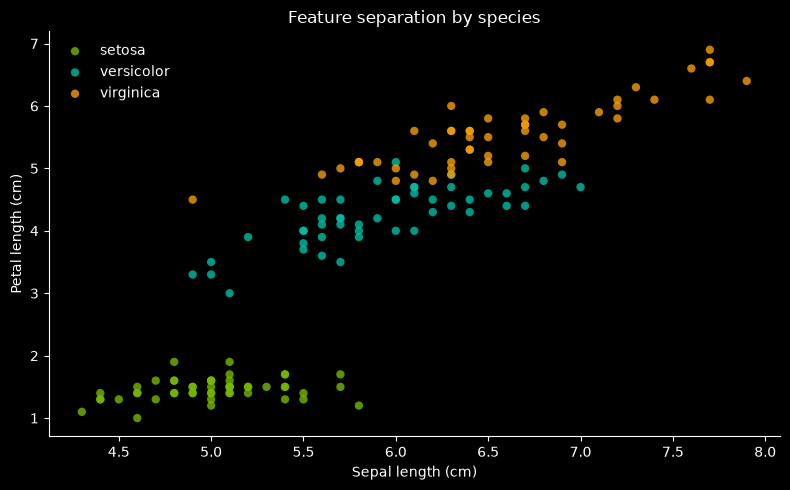

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for species, group in frame.groupby("species", sort=False):
    ax.scatter(
        group["sepal_length_cm"],
        group["petal_length_cm"],
        label=species,
        color=CLASS_COLORS[species],
        alpha=0.8,
        edgecolor="none",
    )
ax.set(
    title="Feature separation by species",
    xlabel="Sepal length (cm)",
    ylabel="Petal length (cm)",
)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Prove that the guardrail fails closed

A negative physical measurement should never reach training. Here we inject one invalid value and call the same validator used by the production pipeline.

In [6]:
invalid_features = dataset.features.copy()
invalid_features.loc[0, "sepal_length_cm"] = -1.0
invalid_dataset = Dataset(invalid_features, dataset.target, dataset.target_names)

try:
    validate_dataset(invalid_dataset)
except ValueError as error:
    print(f"Validation blocked the dataset: {error}")

Validation blocked the dataset: Iris measurements cannot be negative


## Takeaways

- The dataset is small, complete, non-negative, and perfectly class-balanced.
- The four-feature schema is explicit and enforced in package code.
- Visible feature separation supports a simple, interpretable baseline model.
- Validation fails before training, keeping malformed inputs out of tracked experiments.